# Учись Машина Учись / Learn Machine Learn

<img src="data/lml.png" width=200>

Онлайн-лекции Ильи С. Елисеева: применение методов машинного обучения в анализе данных.

- Канал в Telegram: https://t.me/learn_machine_learn
- YouTube: https://www.youtube.com/channel/UCCwDwKatNitBCVAJajremMQ
- VK: https://vk.com/learn_machine_learn
- GitHub: https://github.com/easyise/learn_machine_learn

---



# Лекция 4. Латентные пространства


In [ ]:
!pip install torchinfo torchmetrics

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torchinfo import summary

%matplotlib inline

device = "cuda" if torch.cuda.is_available() else \
    "mps" if torch.backends.mps.is_built() else "cpu"
device

'cuda'

### 1. Создание латентных пространств

Основная идея: снижение размерности данных с сохранением их ключевых характеристик, да еще и так, чтобы сохранилась возможность восстановления исходных данных из этого компактного представления.

То есть из, допустим, 784 признаков (например, изображения 28x28 пикселей) мы хотим получить 2 признака, и потом из этих 2 признаков мы хотим восстановить исходные 784 признака (то есть изображение).

Посмотрим на примере рукописных цифр из датасета MNIST.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

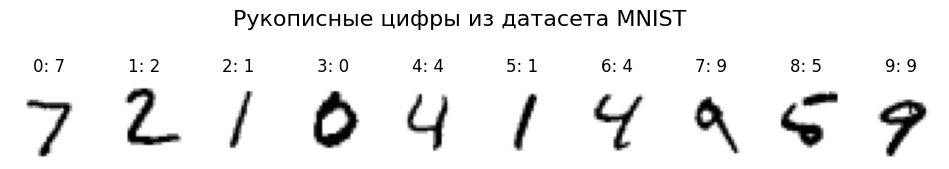

In [4]:
images, labels = next(iter(test_loader))

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray_r")
    plt.title(f"{i}: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Рукописные цифры из датасета MNIST", fontsize=16)
plt.show()

In [ ]:
images[0].shape

In [ ]:
(images[0].squeeze().numpy() * 256).astype(np.uint8)


## 1.1 Метод главных компонент (PCA)

Простейший способ: создаются новые признаки, каждый из которых является линейной комбинацией исходных признаков. Для данного набора данных с таким алгоритмом два признака - слишком мало, чтобы можно было восстановить исходные данные.

In [5]:
from sklearn.decomposition import PCA

sample_size = 2000
X = test_dataset.data[:sample_size].numpy().reshape(sample_size, -1) / 255.0
y = test_dataset.targets[:sample_size].numpy()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)


In [6]:
def show_latent_space(z1, z2, y, ax, A=None, B=None, points=None, **kwargs):

    scatter = ax.scatter(
        z1,
        z2,
        c=y,
        cmap="tab10",
        s=5,
        alpha=0.75,
        **kwargs
    )

    if(A is not None and B is not None):
        # прямая между выбранными точками
        plt.plot(
            [A[0], B[0]],
            [A[1], B[1]],
            "k--",
            linewidth=2,
            alpha=0.5,
            label="Линия интерполяции"
        )

        # выделяем выбранные точки
        plt.scatter(
            [A[0], B[0]],
            [A[1], B[1]],
            c=["lime", "red"],
            s=100,
            edgecolors="gray",
            zorder=3
        )

    if points is not None:
        plt.scatter(points[:, 0], points[:, 1], c="black", s=20, marker="x")  # точки

    ax.set_xlabel("z1" if 'xlabel' not in kwargs else kwargs['xlabel'])
    ax.set_ylabel("z2" if 'ylabel' not in kwargs else kwargs['ylabel'])
    ax.set_title("Latent Space Representation")
    ax.figure.colorbar(scatter, ax=ax, label="Digit Class")
    ax.grid(alpha=0.2)


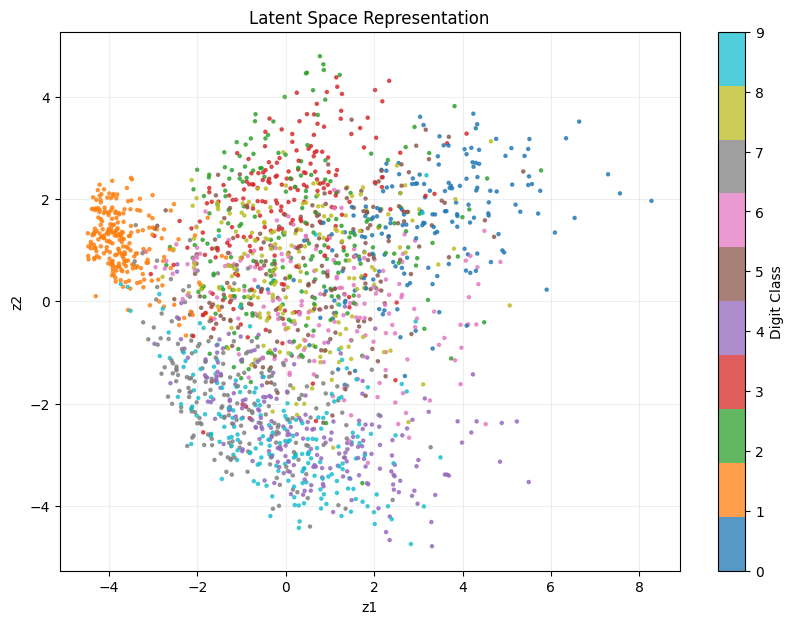

In [7]:
plt.figure(figsize=(10, 7))
show_latent_space(X_pca[:, 0], X_pca[:, 1], y, plt.gca())

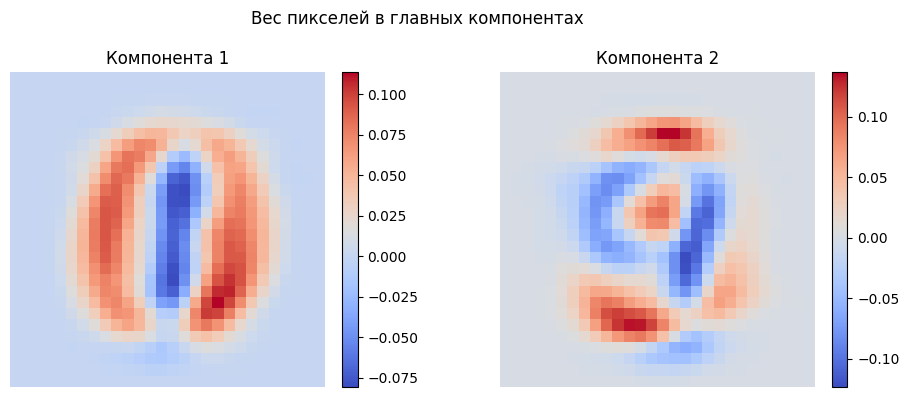

Доля объясненной дисперсии:
Компонента 1: 9.71%
Компонента 2: 7.56%

Компонента 1: 10 самых важных пикселей
 1. px_20_18 (строка=20, столбец=18) -> вес +0.1136
 2. px_19_19 (строка=19, столбец=19) -> вес +0.1076
 3. px_19_18 (строка=19, столбец=18) -> вес +0.1065
 4. px_18_19 (строка=18, столбец=19) -> вес +0.1044
 5. px_21_17 (строка=21, столбец=17) -> вес +0.1021
 6. px_21_18 (строка=21, столбец=18) -> вес +0.0991
 7. px_20_19 (строка=20, столбец=19) -> вес +0.0984
 8. px_20_17 (строка=20, столбец=17) -> вес +0.0983
 9. px_17_19 (строка=17, столбец=19) -> вес +0.0970
10. px_17_20 (строка=17, столбец=20) -> вес +0.0942

Компонента 2: 10 самых важных пикселей
 1. px_5_15 (строка=5, столбец=15) -> вес +0.1365
 2. px_5_14 (строка=5, столбец=14) -> вес +0.1355
 3. px_22_11 (строка=22, столбец=11) -> вес +0.1328
 4. px_22_12 (строка=22, столбец=12) -> вес +0.1320
 5. px_22_10 (строка=22, столбец=10) -> вес +0.1232
 6. px_16_16 (строка=16, столбец=16) -> вес -0.1231
 7. px_5_16 (строка=5, с

In [8]:
component_maps = pca.components_.reshape(2, 28, 28)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for idx, ax in enumerate(axes):
    im = ax.imshow(component_maps[idx], cmap="coolwarm")
    ax.set_title(f"Компонента {idx + 1}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Вес пикселей в главных компонентах")
plt.tight_layout()
plt.show()

print("Доля объясненной дисперсии:")
for idx, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"Компонента {idx}: {ratio * 100:.2f}%")

feature_names = [f"px_{row}_{col}" for row in range(28) for col in range(28)]

for idx, component in enumerate(pca.components_, start=1):
    sorted_idx = np.argsort(np.abs(component))[::-1][:10]
    print(f"\nКомпонента {idx}: 10 самых важных пикселей")
    for rank, pixel_idx in enumerate(sorted_idx, start=1):
        row, col = divmod(pixel_idx, 28)
        weight = component[pixel_idx]
        print(
            f"{rank:>2}. {feature_names[pixel_idx]} (строка={row}, столбец={col}) -> вес {weight:+.4f}"
        )


**ВЫВОД**: Обе компоненты объясняют только 17% дисперсии данных, что недостаточно для восстановления исходных изображений.

## 1.2 Латентное пространство Autoencoder'а 

Линейных преобразований на основе PCA недостаточно, чтобы восстановить исходные данные. Поэтому нужно использовать более сложные методы, например, нейронные сети.

Строим полносвязную сеть, которая будет сжимать данные в 2 признака (encoder) и соединяем ее с симметричной сетью, которая будет восстанавливать исходные данные (decoder). 

В итоге получаем autoencoder.

In [9]:
# картинка 28×28 = 784 числа сжимается всего в 2 числа
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_neurons=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_neurons),
            nn.ReLU(),
            nn.Linear(hidden_neurons, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_neurons),
            nn.ReLU(),
            nn.Linear(hidden_neurons, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        x_reconstructed = x_reconstructed.view(-1, 1, 28, 28)
        return x_reconstructed

model = Autoencoder(latent_dim=2).to(device)

summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 2]                    --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 128]                  100,480
│    └─ReLU: 2-3                         [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Linear: 2-6                       [1, 2]                    130
├─Sequential: 1-2                        [1, 784]                  --
│    └─Linear: 2-7                       [1, 64]                   192
│    └─ReLU: 2-8                         [1, 64]                   --
│    └─Linear: 2-9                       [1, 128]                  8,320
│    └─ReLU: 2-10                        [1, 128]                  --
│ 

In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        reconstructed = model(images)
        loss = criterion(reconstructed, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")

Epoch [1/20], Loss: 0.0752
Epoch [2/20], Loss: 0.0533
Epoch [3/20], Loss: 0.0502
Epoch [4/20], Loss: 0.0477
Epoch [5/20], Loss: 0.0461
Epoch [6/20], Loss: 0.0451
Epoch [7/20], Loss: 0.0444
Epoch [8/20], Loss: 0.0438
Epoch [9/20], Loss: 0.0433
Epoch [10/20], Loss: 0.0428
Epoch [11/20], Loss: 0.0424
Epoch [12/20], Loss: 0.0420
Epoch [13/20], Loss: 0.0417
Epoch [14/20], Loss: 0.0414
Epoch [15/20], Loss: 0.0411
Epoch [16/20], Loss: 0.0409
Epoch [17/20], Loss: 0.0407
Epoch [18/20], Loss: 0.0405
Epoch [19/20], Loss: 0.0404
Epoch [20/20], Loss: 0.0402


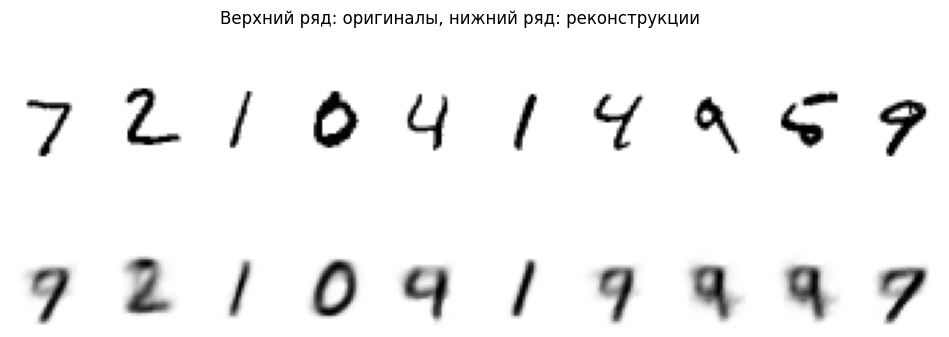

In [11]:
# делаем реконструкцию 10 тестовых изображений и сравниваем их с оригиналами
model.eval()

images, labels = next(iter(test_loader))
images = images[:10].to(device)

with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(12, 4))

for i in range(10):
    # оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray_r")
    plt.axis("off")

    # реконструкция
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray_r")
    plt.axis("off")

plt.suptitle("Верхний ряд: оригиналы, нижний ряд: реконструкции")
plt.show()

In [12]:
# получим латентные представления для всех тестовых изображений
model.eval()

latent_images = []
latent_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        z = model.encoder(images)

        latent_images.append(z.cpu().numpy())
        latent_labels.append(labels.numpy())

latent_images = np.concatenate(latent_images)
latent_labels = np.concatenate(latent_labels)

latent_images.shape, latent_labels.shape

((10000, 2), (10000,))

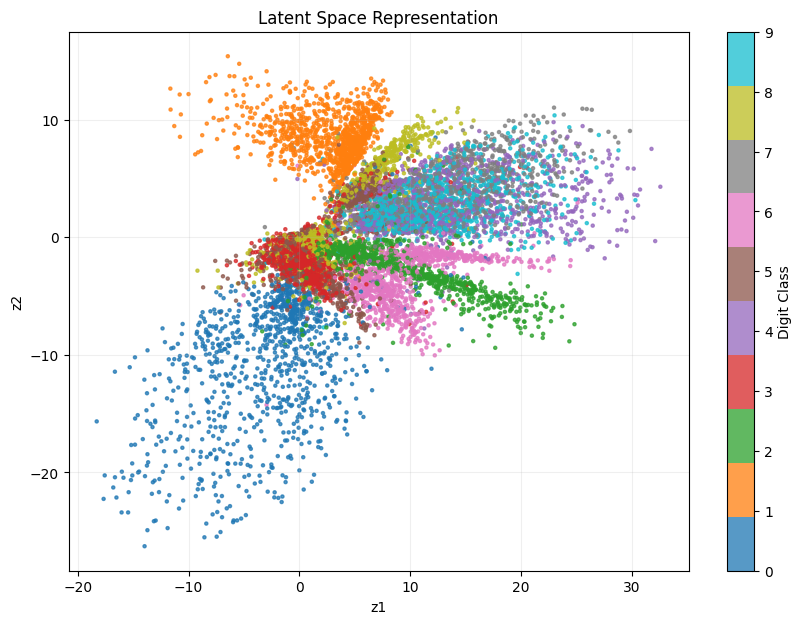

In [13]:
# визуализируем латентное пространство для тестового набора данных
plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images[:, 0],
    latent_images[:, 1],
    latent_labels,
    plt.gca()
)

Выбраны индексы: A=380 (label=0), B=8434 (label=4)


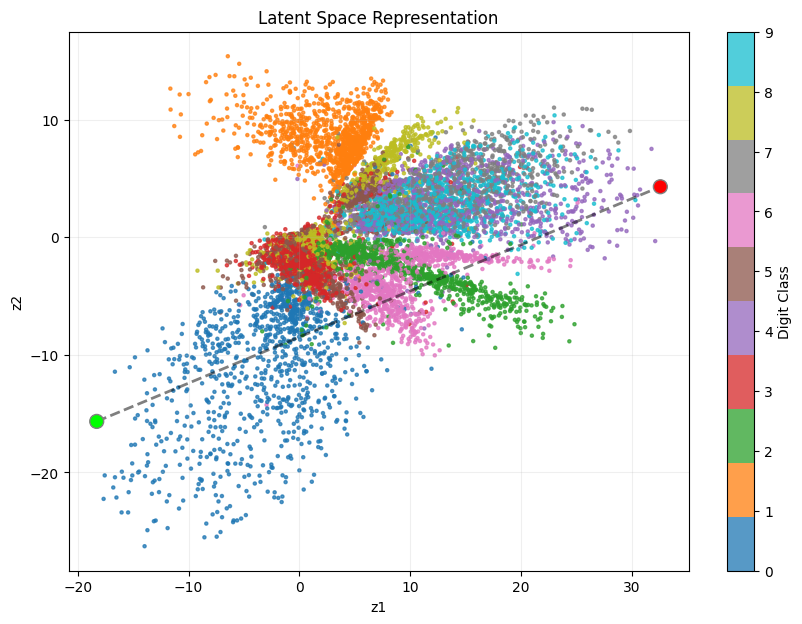

In [14]:
# теперь погуляем по латентному пространству между двумя выбранными точками, чтобы увидеть, как меняются цифры
# выбираем две точки на противоположных концах латентной плоскости
idx_a = int(np.argmin(latent_images[:, 0]))
idx_b = int(np.argmax(latent_images[:, 0]))

point_a = latent_images[idx_a]
point_b = latent_images[idx_b]

# сохраняем цифры в переменные для следующей ячейки
img_a, label_a = test_dataset[idx_a]
img_b, label_b = test_dataset[idx_b]

plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images[:, 0],
    latent_images[:, 1],
    latent_labels,
    plt.gca(),
    A=point_a,
    B=point_b
)

print(f"Выбраны индексы: A={idx_a} (label={label_a}), B={idx_b} (label={label_b})")

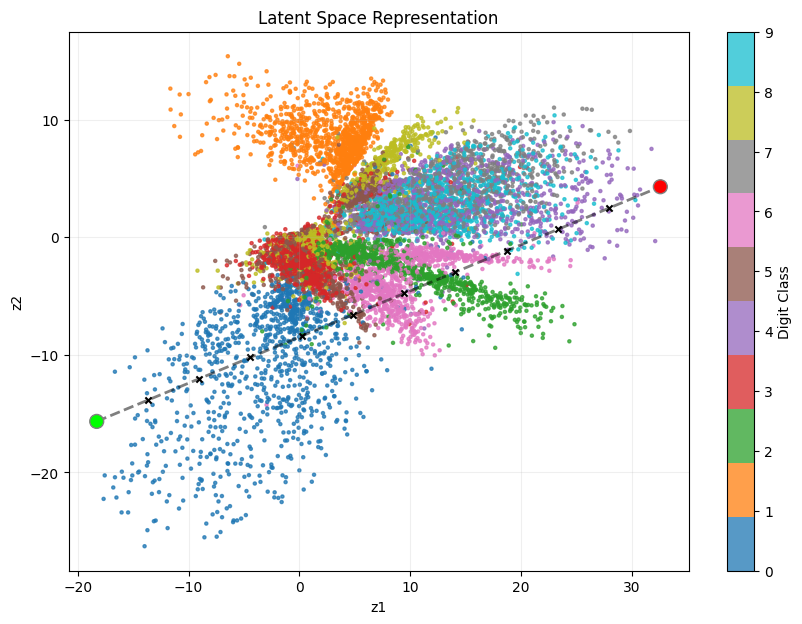

In [15]:
# функция для интерполяции между двумя изображениями в латентном пространстве
def interpolate_images(model, img1, img2, steps=10):
    model.eval()

    img1 = img1.unsqueeze(0).to(device)
    img2 = img2.unsqueeze(0).to(device)

    with torch.no_grad():
        enc1 = model.encoder(img1)
        z1 = enc1[0] if isinstance(enc1, tuple) else enc1  # если энкодер возвращает кортеж (например, для VAE)
        enc2 = model.encoder(img2)
        z2 = enc2[0] if isinstance(enc2, tuple) else enc2

        latent_points = []
        interpolated_images = []

        for alpha in torch.linspace(0, 1, steps).to(device):
            z = (1 - alpha) * z1 + alpha * z2
            latent_points.append(z.cpu())
            decoded = model.decoder(z).view(1, 28, 28)
            interpolated_images.append(decoded.cpu())

    return interpolated_images, latent_points



steps = 12
interpolated_images, latent_points = interpolate_images(model, img_a, img_b, steps=steps)

plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images[:, 0],
    latent_images[:, 1],
    latent_labels,
    plt.gca(),
    A=point_a,
    B=point_b,
    points=torch.cat(latent_points, dim=0).numpy()
)

In [ ]:
from ipywidgets import interact, IntSlider

def show_interpolation(step):
    plt.figure(figsize=(3, 3))
    plt.imshow(interpolated_images[step].squeeze(), cmap="gray_r")
    plt.axis("off")
    plt.title(f"Интерполяция: {label_a} → {label_b}, шаг {step + 1}/{steps}")
    plt.show()


interact(
    show_interpolation,
    step=IntSlider(min=0, max=steps - 1, step=1, value=0, description="Шаг")
);

interactive(children=(IntSlider(value=0, description='Шаг', max=11), Output()), _dom_classes=('widget-interact…

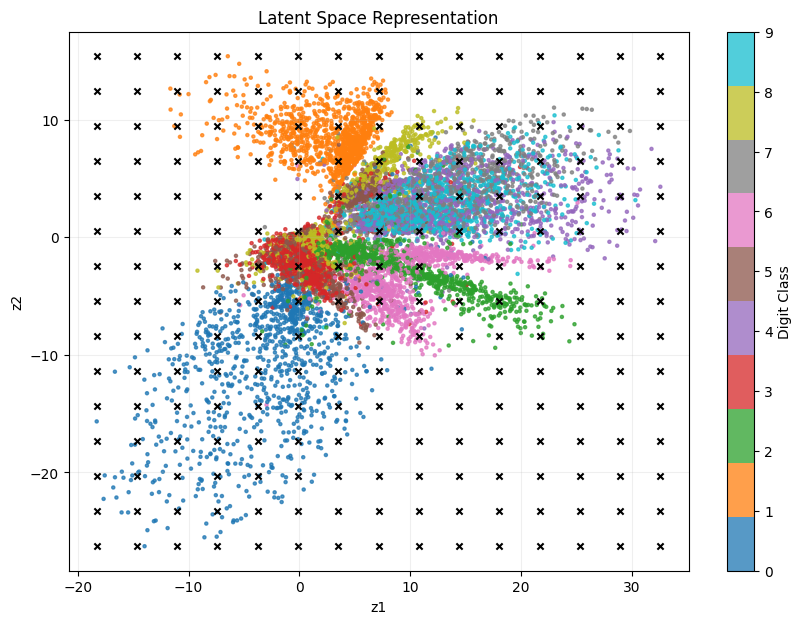

In [17]:
# зададим 15 точек в латентном пространстве и декодируем их в изображения

grid_size = 15
z1_values = np.linspace(latent_images[:, 0].min(), latent_images[:, 0].max(), grid_size)
z2_values = np.linspace(latent_images[:, 1].min(), latent_images[:, 1].max(), grid_size)

mg = np.meshgrid(z1_values, z2_values)
grid_points = np.stack(mg, axis=-1).reshape(-1, 2)

plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images[:, 0],
    latent_images[:, 1],
    latent_labels,
    plt.gca(),
    points=grid_points
)

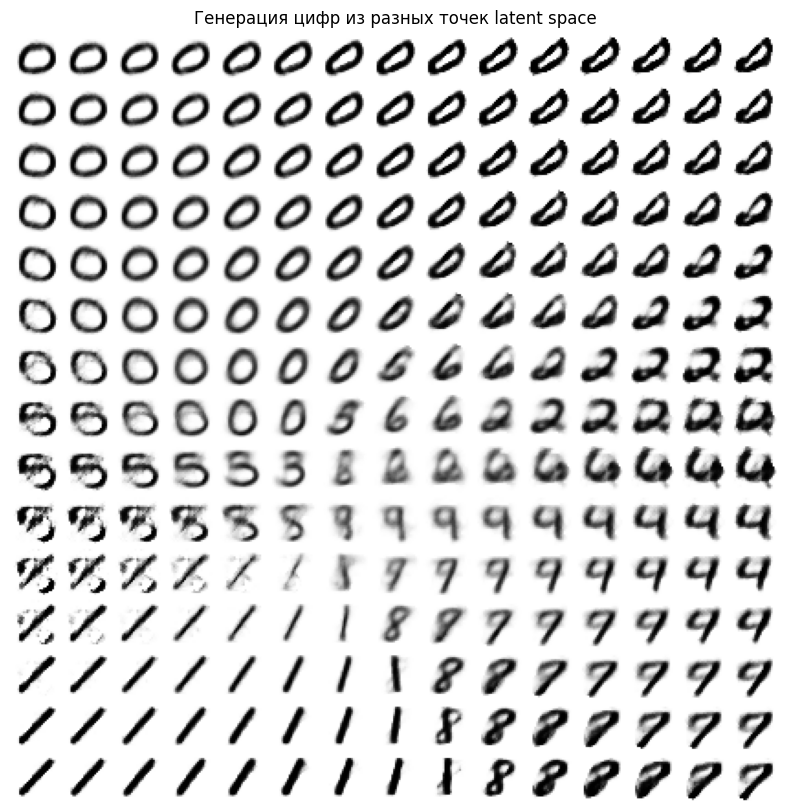

In [18]:
model.eval()

canvas = np.zeros((28 * grid_size, 28 * grid_size))

with torch.no_grad():
    for i, z2 in enumerate(z2_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
            decoded = model.decoder(z).view(28, 28).cpu().numpy()

            canvas[
                i * 28:(i + 1) * 28,
                j * 28:(j + 1) * 28
            ] = decoded

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap="gray_r")
plt.axis("off")
plt.title("Генерация цифр из разных точек latent space")
plt.show()

## 1.3 Вариационные автоэнкодеры (VAE)

Вариационные автоэнкодеры (VAE) - это расширение классических автоэнкодеров, которые вводят стохастический элемент в процесс кодирования и декодирования, что позволяет моделировать распределение данных в латентном пространстве.

**Ключевая идея VAE:**

Обычные автоэнкодеры кодируют так:
```
7 → z = [1.2, -0.8]
```

Вариационные автоэнкодеры кодируют так (почти так):
```
7 → μ=[1.2, -0.8], σ=[0.3, 0.2]
```

В результате получаем латентное пространство:
- гладкое
- непрерывное
- похожее на нормальное распределение.

In [19]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2, hidden_neurons=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_neurons),
            nn.ReLU(),
            nn.Linear(hidden_neurons, 64),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_neurons),
            nn.ReLU(),
            nn.Linear(hidden_neurons, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # функция-семплер для получения z из mu и logvar
    def reparameterize(self, mu, logvar): # log(σ²)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x = self.decoder(z)
        return x.view(-1, 1, 28, 28)

    def forward(self, x):

        mu, logvar = self.encode(x) # закодируй
        z = self.reparameterize(mu, logvar) # сэмплируй из латентного пространства
        reconstructed = self.decode(z) # декодируй обратно в изображение

        return reconstructed, mu, logvar


model_vae = VAE(latent_dim=2).to(device)

In [20]:
# Функция потерь для VAE:
# включает в себя ошибку реконструкции,
# а также KL-дивергенцию между распределением в латентном пространстве и нормальным распределением
# то есть:
#  - ошибку реконструкции (насколько хорошо декодер восстанавливает изображение)
#  - штраф за плохое латентное пространство

def vae_loss(reconstructed, x, mu, logvar):
    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstructed,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss

In [21]:
optimizer = optim.Adam(model_vae.parameters(), lr=1e-3)

epochs = 20

for epoch in range(epochs):
    model_vae.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        reconstructed, mu, logvar = model_vae(images)
        loss = vae_loss(reconstructed, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 225.0173
Epoch [2/20], Loss: 178.4440
Epoch [3/20], Loss: 169.0246
Epoch [4/20], Loss: 165.4448
Epoch [5/20], Loss: 162.4058
Epoch [6/20], Loss: 159.8445
Epoch [7/20], Loss: 157.9719
Epoch [8/20], Loss: 156.4511
Epoch [9/20], Loss: 155.2394
Epoch [10/20], Loss: 154.2362
Epoch [11/20], Loss: 153.4350
Epoch [12/20], Loss: 152.6726
Epoch [13/20], Loss: 152.1158
Epoch [14/20], Loss: 151.4999
Epoch [15/20], Loss: 150.8375
Epoch [16/20], Loss: 150.2528
Epoch [17/20], Loss: 149.6720
Epoch [18/20], Loss: 149.1464
Epoch [19/20], Loss: 148.5713
Epoch [20/20], Loss: 148.1261


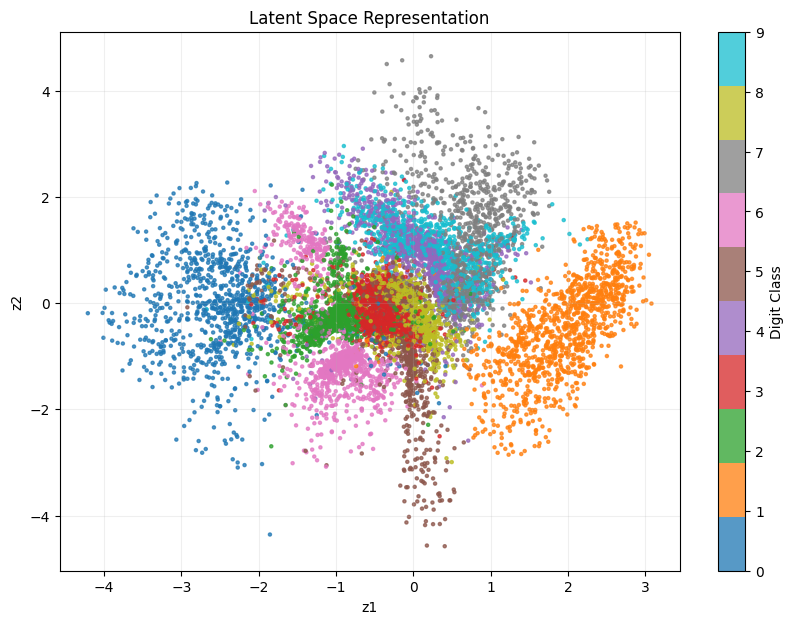

In [22]:
# визуализируем латентное пространство, в котором каждая точка — это мат. ожидание латентного вектора, а цвет — её класс
model.eval()

latent_images_vae = []
latent_labels_vae = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        mu, logvar = model_vae.encode(images)

        latent_images_vae.append(mu.cpu().numpy())
        latent_labels_vae.append(labels.numpy())

latent_images_vae = np.concatenate(latent_images_vae)
latent_labels_vae = np.concatenate(latent_labels_vae)

plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images_vae[:, 0],
    latent_images_vae[:, 1],
    latent_labels_vae,
    plt.gca()
)

In [23]:
# интерполяция между двумя изображениями в латентном пространстве VAE
def interpolate_vae(model, img1, img2, steps=12):
    model.eval()

    img1 = img1.unsqueeze(0).to(device)
    img2 = img2.unsqueeze(0).to(device)

    with torch.no_grad():
        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        points = []
        images = []

        for alpha in torch.linspace(0, 1, steps).to(device):
            z = (1 - alpha) * mu1 + alpha * mu2
            points.append(z.cpu())
            decoded = model.decode(z)
            images.append(decoded.cpu())

    return images, points

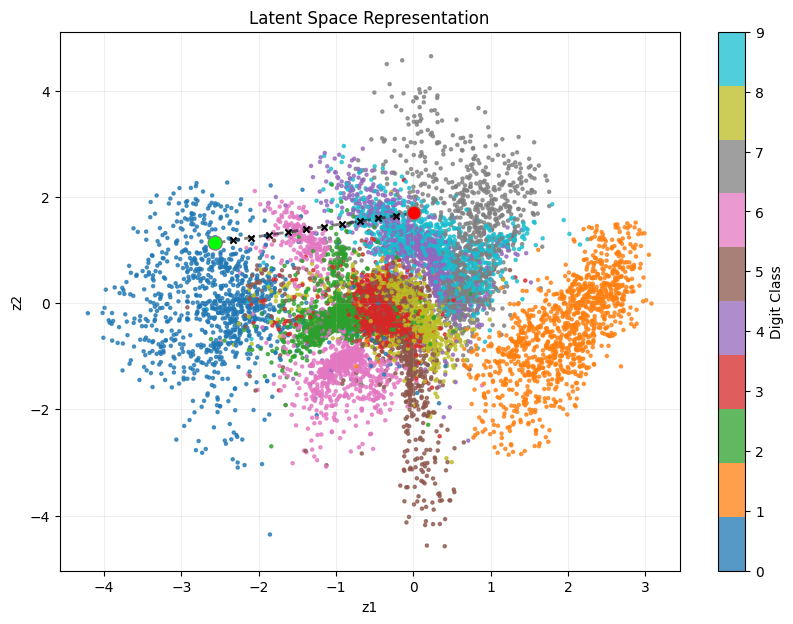

In [24]:
# погуляем по латентному пространству и посмотрим, что нам встретится на пути.
# найдем те же точки, что и в предыдущем примере, но теперь в латентном пространстве VAE
point_a = latent_images_vae[idx_a]
point_b = latent_images_vae[idx_b]

steps = 12
interpolated_images, latent_points = interpolate_vae(model_vae, img_a, img_b, steps=steps)

plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images_vae[:, 0],
    latent_images_vae[:, 1],
    latent_labels,
    plt.gca(),
    A=point_a,
    B=point_b,
    points=torch.cat(latent_points, dim=0).numpy()
)

In [ ]:
def show_interpolation(step):
    plt.figure(figsize=(3, 3))
    plt.imshow(interpolated_images[step].squeeze(), cmap="gray_r")
    plt.axis("off")
    plt.title(f"Интерполяция: {label_a} → {label_b}, шаг {step + 1}/{steps}")
    plt.show()


interact(
    show_interpolation,
    step=IntSlider(min=0, max=steps - 1, step=1, value=0, description="Шаг")
);

interactive(children=(IntSlider(value=0, description='Шаг', max=11), Output()), _dom_classes=('widget-interact…

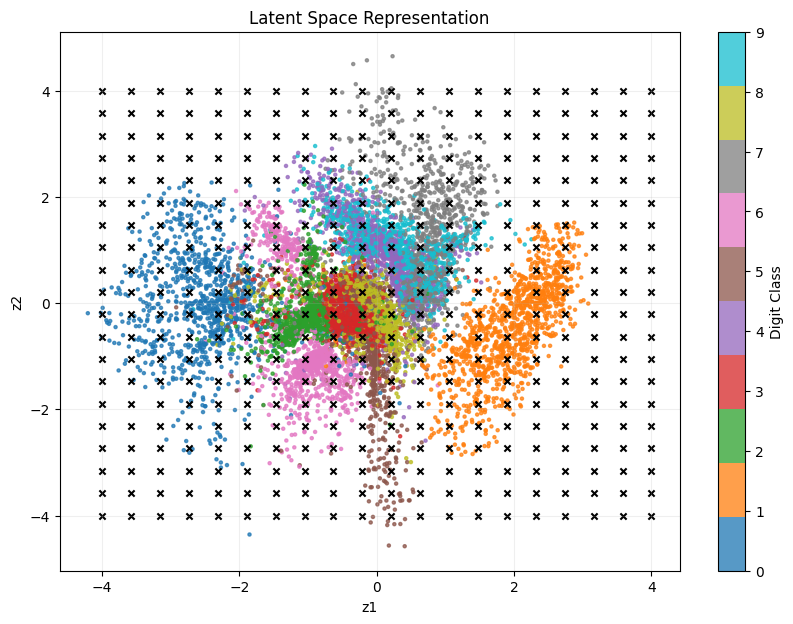

In [26]:
grid_size = 20
z1_values = np.linspace(-4, 4, grid_size)
z2_values = np.linspace(-4, 4, grid_size)

mg = np.meshgrid(z1_values, z2_values)
grid_points = np.stack(mg, axis=-1).reshape(-1, 2)

plt.figure(figsize=(10, 7))
show_latent_space(
    latent_images_vae[:, 0],
    latent_images_vae[:, 1],
    latent_labels,
    plt.gca(),
    points=grid_points
)

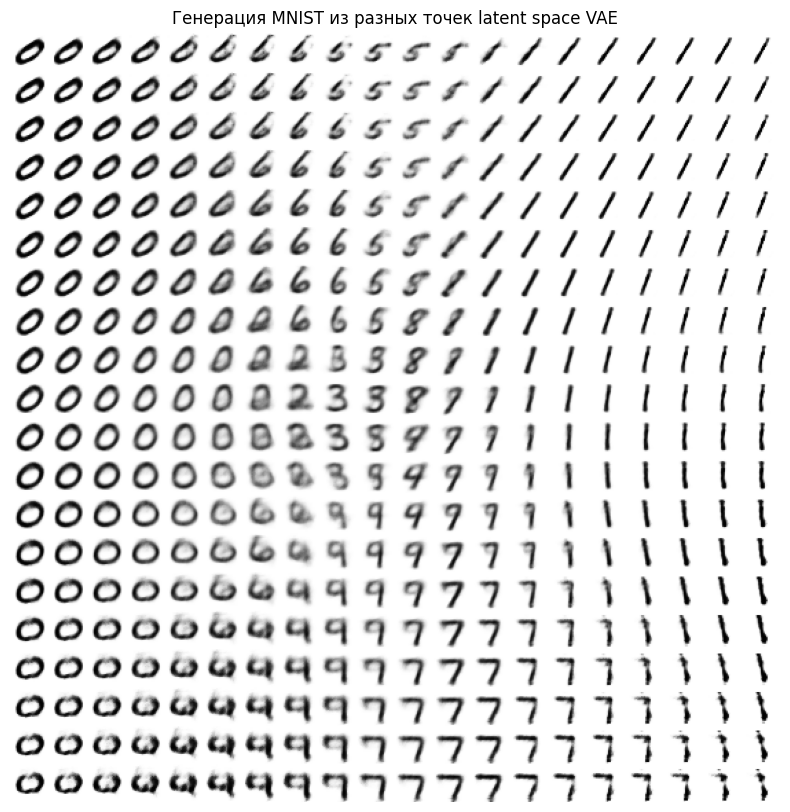

In [27]:
model_vae.eval()

canvas = np.zeros((28 * grid_size, 28 * grid_size))

with torch.no_grad():
    for i, z2 in enumerate(z2_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
            generated = model_vae.decode(z).squeeze().cpu().numpy()

            canvas[
                i * 28:(i + 1) * 28,
                j * 28:(j + 1) * 28
            ] = generated

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap="gray_r")
plt.axis("off")
plt.title("Генерация MNIST из разных точек latent space VAE")
plt.show()

## 1.4 🌡️ Температура сэмплирования из латентного пространства

Познакомимся с таким параметром, как `temperature`, который позволяет контролировать разнообразие генерируемых примеров:
```
temperature = 0.0 → почти обычный autoencoder, берём только mu
temperature = 0.5 → аккуратные вариации
temperature = 1.0 → стандартный VAE
temperature = 2.0 → более разнообразные, но менее стабильные изображения

In [28]:
def sample_z(mu, logvar, temperature=1.0):
    """
    Сэмплирует z из распределения, заданного mu и logvar, с контролем температуры.
    - mu: мат. ожидание латентного вектора
    - logvar: логарифм дисперсии латентного вектора
    - temperature: параметр, контролирующий разнообразие генерируемых примеров (чем выше, тем более разнообразные примеры)
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + temperature * eps * std
    return z

T: 0.0 z: [-0.75232166  1.1443715 ]
T: 0.25 z: [-0.7635541  1.142888 ]
T: 0.5 z: [-0.77139693  1.1667167 ]
T: 1.0 z: [-0.8190952  1.1812128]
T: 1.5 z: [-0.7539603  1.095929 ]
T: 2.0 z: [-0.90554386  1.2169476 ]
T: 4.0 z: [-0.10966659  0.76218987]
T: 8.0 z: [-0.86482745  0.34738922]
T: 16.0 z: [-0.68874985  0.9534975 ]


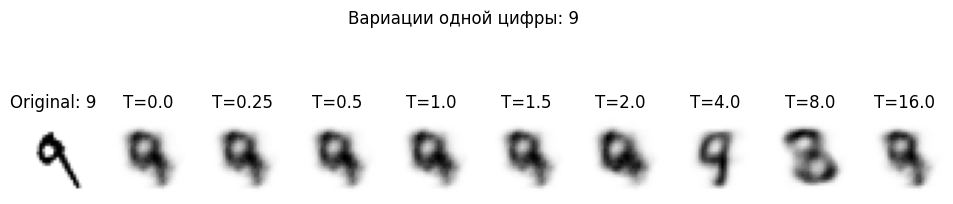

In [29]:
model_vae.eval()

img_src, label = test_dataset[7]
img = img_src.unsqueeze(0).to(device)

with torch.no_grad():
    mu, logvar = model_vae.encode(img)

temperatures = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 4.0, 8.0, 16.0]

plt.figure(figsize=(12, 3))

plt.subplot(1, len(temperatures) + 1, 1)
plt.imshow(img_src[0, :, :], cmap="gray_r")
plt.axis("off")
plt.title(f"Original: {label}")

for i, t in enumerate(temperatures):
    with torch.no_grad():
        z = sample_z(mu, logvar, temperature=t)
        print("T: {} z: {}".format(t, z.cpu().numpy().flatten()))
        generated = model_vae.decode(z).cpu()

    plt.subplot(1, len(temperatures) + 1, i + 1 + 1)
    plt.imshow(generated.squeeze(), cmap="gray_r")
    plt.axis("off")
    plt.title(f"T={t}")

plt.suptitle(f"Вариации одной цифры: {label}")
plt.show()

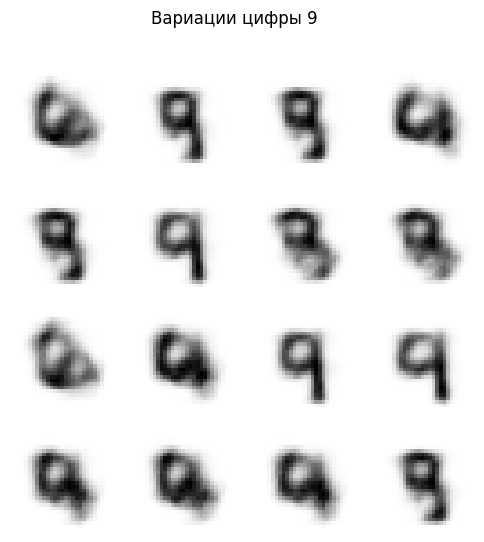

In [32]:
# вариации одной цифры с разными температурами
def generate_variations(model, image, n=16, temperature=1.0):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        mu, logvar = model.encode(image)

        images = []
        for _ in range(n):
            z = sample_z(mu, logvar, temperature=temperature)
            decoded = model.decode(z).cpu()
            images.append(decoded)

    return images

img, label = test_dataset[7]

variations = generate_variations(
    model_vae,
    img,
    n=16,
    temperature=4.0
)

plt.figure(figsize=(6, 6))

for i, generated in enumerate(variations):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated.squeeze(), cmap="gray_r")
    plt.axis("off")

plt.suptitle(f"Вариации цифры {label}")
plt.show()

In [ ]:
import gc

model.to('cpu')
del model

model_vae.to('cpu')
del model_vae

gc.collect()
torch.cuda.empty_cache() 

## 2. Латентное пространство диффузионных моделей

Размерность латентного пространства здесь гораздо выше, чем в случае VAE. Например, для модели Stable Diffusion размерность латентного пространства составляет 4x64x64 = 16384 признаков.

И в таком пространстве можно делать всякие интересные вещи, например, интерполяцию между изображениями по сиду и промпту.



In [34]:
!pip install -U diffusers transformers accelerate safetensors

In [36]:
# Helper functions

def make_latents(seed, width=832, height=832):
    
    # создаем шум в латентном пространстве с заданным сидом
    generator = torch.Generator(device=device).manual_seed(seed)

    latents = torch.randn(
        (1, pipe.unet.config.in_channels, height // 8, width // 8),
        generator=generator,
        device=device,
        dtype=dtype,
    )

    return latents


def show_grid(images, titles=None, cols=5, figsize=(16, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

        if titles:
            plt.title(titles[i], fontsize=9)

    plt.tight_layout()
    plt.show()


def encode_prompt(prompt):
    text_inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )

    text_input_ids = text_inputs.input_ids.to(device)

    with torch.no_grad():
        prompt_embeds = pipe.text_encoder(text_input_ids)[0]

    return prompt_embeds


def lerp(t, a, b):
    return (1 - t) * a + t * b


def slerp(t, v0, v1, dot_threshold=0.9995):
    v0_float = v0.float()
    v1_float = v1.float()

    v0_norm = v0_float / torch.norm(v0_float)
    v1_norm = v1_float / torch.norm(v1_float)

    dot = torch.sum(v0_norm * v1_norm)

    if torch.abs(dot) > dot_threshold:
        return lerp(t, v0, v1)

    theta_0 = torch.acos(dot)
    sin_theta_0 = torch.sin(theta_0)

    theta_t = theta_0 * t
    sin_theta_t = torch.sin(theta_t)

    s0 = torch.sin(theta_0 - theta_t) / sin_theta_0
    s1 = sin_theta_t / sin_theta_0

    return s0 * v0 + s1 * v1

In [40]:
import torch
from pathlib import Path

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

In [81]:
# MODEL_PATH = Path("~/models/checkpoints/Deliberate_v6 (SFW).safetensors").expanduser()
# MODEL_PATH = Path("~/models/checkpoints/Deliberate_v2.safetensors").expanduser()
MODEL_PATH = Path("~/models/checkpoints/juggernaut_aftermath.safetensors").expanduser()
# MODEL_PATH = Path("~/models/checkpoints/Realistic_Vision_V3.0.safetensors").expanduser()

# или:
# MODEL_PATH = Path("~/models/CyberRealistic.safetensors").expanduser()

device = "cuda"
dtype = torch.float16

pipe = StableDiffusionPipeline.from_single_file(
    MODEL_PATH,
    torch_dtype=dtype,
    safety_checker=None,
    local_files_only=True,
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    use_karras_sigmas=True
)

pipe = pipe.to(device)
pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For

In [50]:
pipe.device

device(type='cuda', index=0)

In [82]:
width = 512
height = 768
steps = 30
guidance_scale = 7

base_prompt = """
RAW photo, realistic portrait photograph of young woman,
warm smile, spandex, city park background,
frontal face, portrait,
straight-on view,
looking directly into camera,
head centered,
front-facing portrait,
head and shoulders only,
masterpiece, detailed skin texture, realistic lighting, soft shadows, cinematic lighting, bokeh,
"""

prompts = [
    base_prompt.replace(
        "young woman",
        "young chubby Nordic woman, long blonde hair, blue eyes"
    ),

    base_prompt.replace(
        "young woman",
        "chubby young redhead Irish woman, red hair, green eyes"
    ),

    base_prompt.replace(
        "young woman",
        "chubby young East European woman, chestnut brown hair, hazel eyes"
    ),

    base_prompt.replace(
        "young woman",
        "young chubby Italian woman, curly black hair, dark brown eyes"
    ),

    base_prompt.replace(
        "young woman",
        "young chubby East Asian woman, straight black hair, dark brown eyes"
    ),
]

seeds = [int(x) for x in np.array([101, 202, 303, 404, 505]) * 100500]
seeds

[10150500, 20301000, 30451500, 40602000, 50752500]

In [83]:
negative_prompt = """
profile,
side view,
three quarter view,
3/4 view,
standing,
sitting,
waist,
breasts,
looking away,
looking sideways,
looking to the side,
head tilt,
tilted head,
rotated body,
shoulder turned,
over the shoulder,
dynamic pose,
candid photo,
hand on face,
hand near face,
cropped face,
close-up
"""


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [',']


  0%|          | 0/30 [00:00<?, ?it/s]

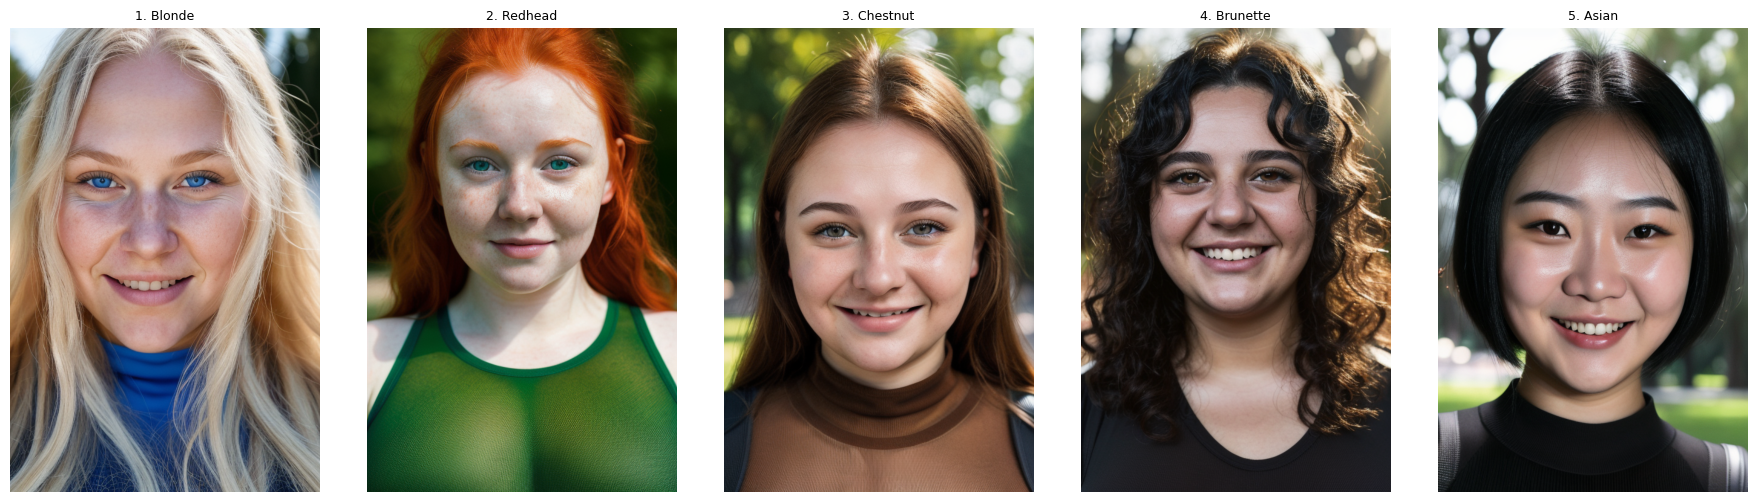

In [84]:

vertex_latents = [make_latents(seed, width, height) for seed in seeds]
vertex_embeds = [encode_prompt(prompt) for prompt in prompts]
negative_embeds = encode_prompt(negative_prompt)

vertex_images = []

for prompt, latents in zip(prompts, vertex_latents):
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        latents=latents,
        width=width,
        height=height,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
    ).images[0]

    vertex_images.append(image)

show_grid(
    vertex_images,
    titles=[
        "1. Blonde",
        "2. Redhead",
        "3. Chestnut",
        "4. Brunette",
        "5. Asian",
    ],
    cols=5,
    figsize=(18, 5)
)

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

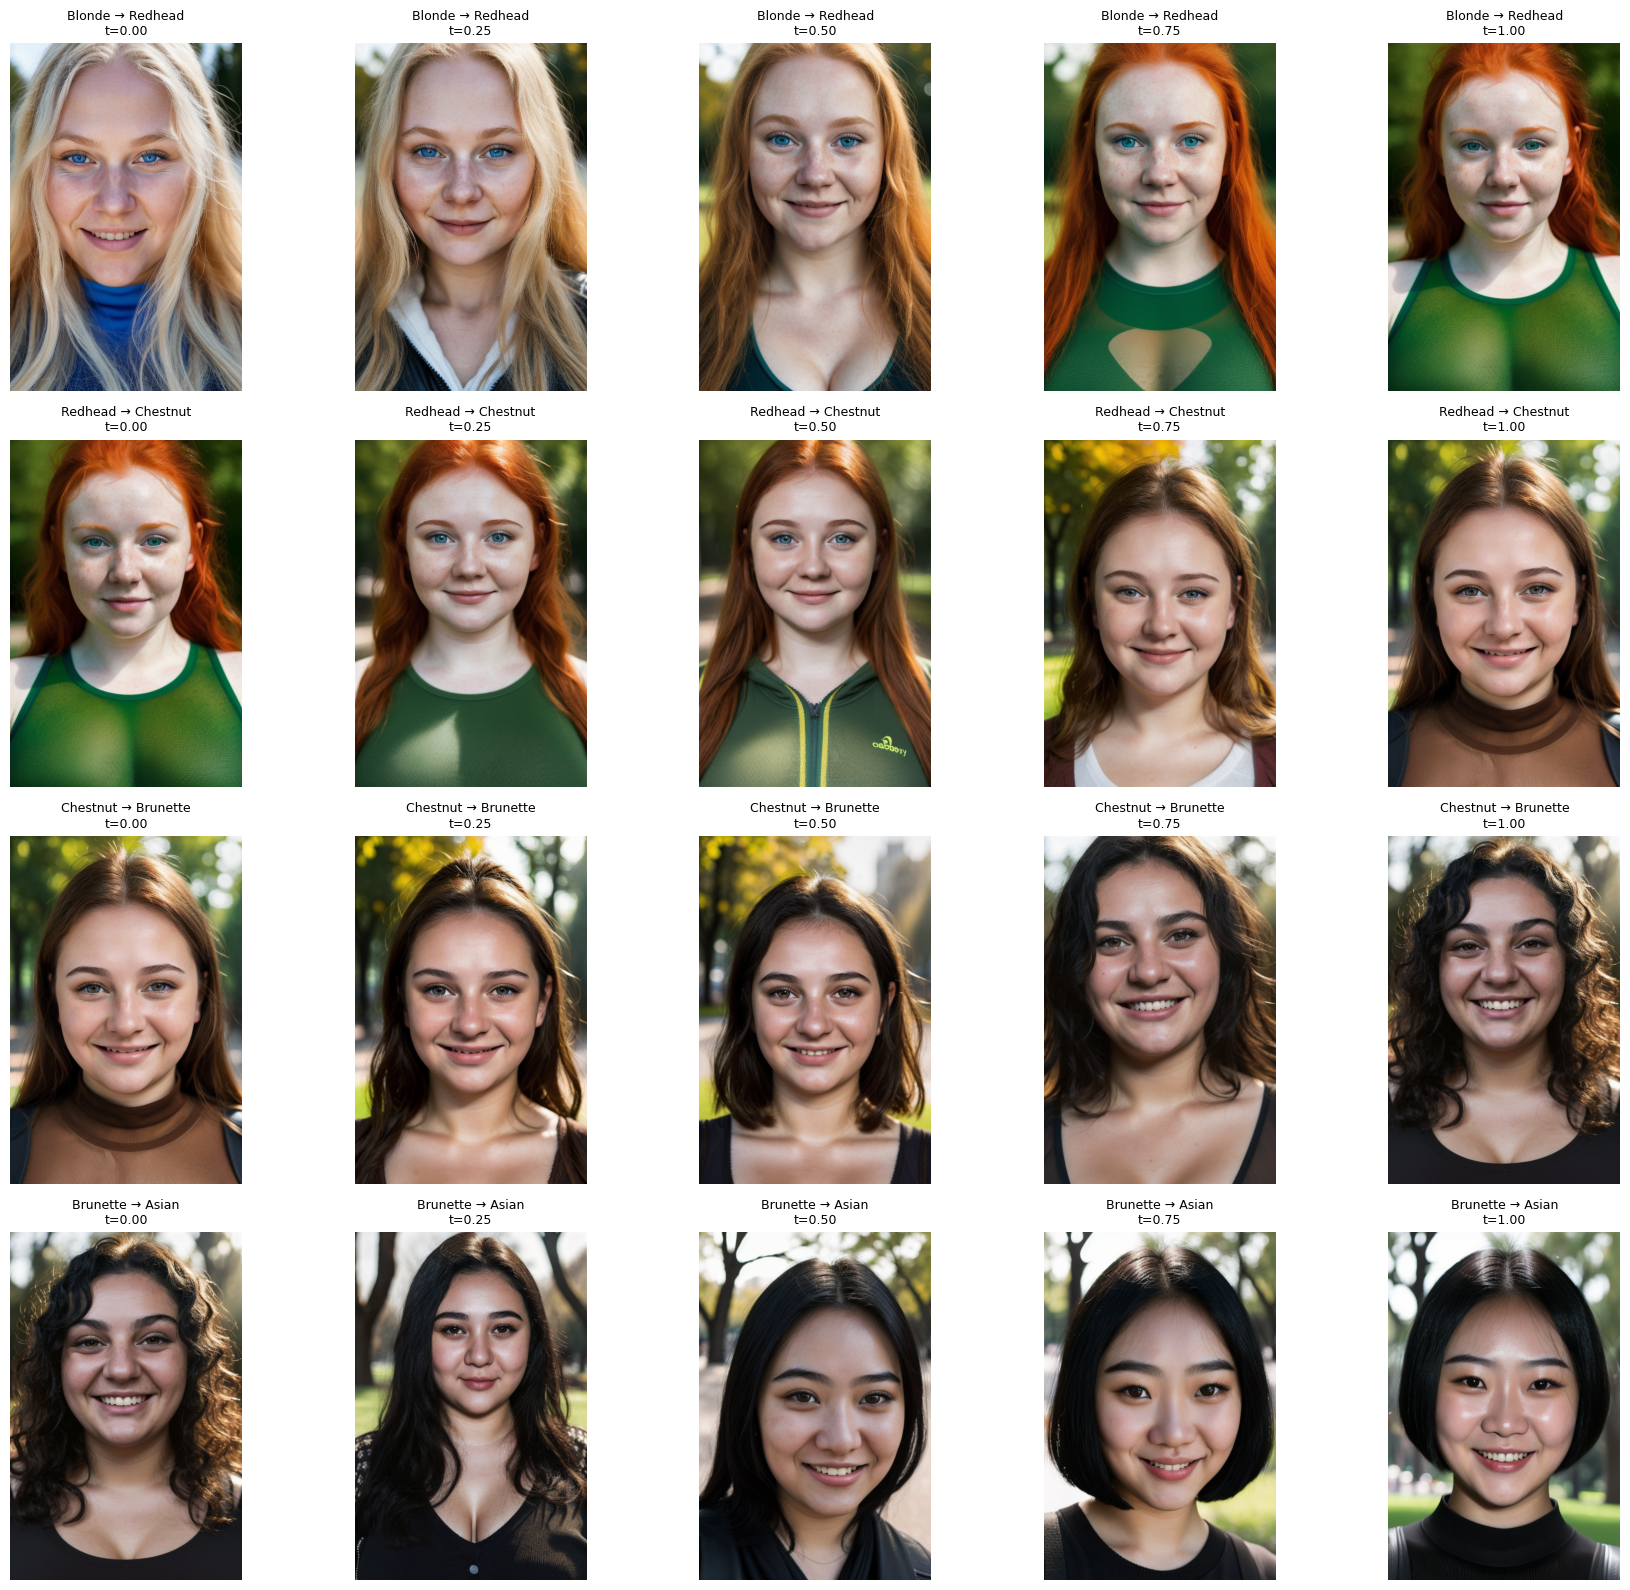

In [85]:
images = []
titles = []

points_per_stage = 5

stage_names = [
    "Blonde → Redhead",
    "Redhead → Chestnut",
    "Chestnut → Brunette",
    "Brunette → Asian",
]

for stage_idx in range(4):
    latents_a = vertex_latents[stage_idx]
    latents_b = vertex_latents[stage_idx + 1]

    embeds_a = vertex_embeds[stage_idx]
    embeds_b = vertex_embeds[stage_idx + 1]

    for local_idx in range(points_per_stage):
        t = local_idx / (points_per_stage - 1)

        latents_t = slerp(t, latents_a, latents_b)
        embeds_t = lerp(t, embeds_a, embeds_b)

        image = pipe(
            prompt_embeds=embeds_t,
            negative_prompt_embeds=negative_embeds,
            latents=latents_t,
            width=width,
            height=height,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
        ).images[0]

        images.append(image)
        titles.append(f"{stage_names[stage_idx]}\nt={t:.2f}")

show_grid(
    images,
    titles=titles,
    cols=5,
    figsize=(18, 16)
)

In [86]:
# Сохранение кадров

out_dir = Path("latent_walk_20_frames")
out_dir.mkdir(exist_ok=True)

for i, img in enumerate(images):
    img.save(out_dir / f"frame_{i:02d}.png")

In [87]:
images[0].save(
    "latent_walk_blonde_to_asian.gif",
    save_all=True,
    append_images=images[1:],
    duration=300,
    loop=0,
)